In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stats
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings("ignore")

# 1-Load the dataset

In [2]:
df=pd.read_csv('credit_card_fraud_2026.csv')

# # 2-Understand the dataset

In [3]:
df.head(2)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0


In [4]:
df.tail()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
19995,19996,41.40,Healthcare,Mastercard,OTP,POS,Android Phone,False,8.82,2,...,False,False,0,17.3,2,3,False,29.6,1,0
19996,19997,47.92,Online Retail,Visa,OTP,POS,Android Phone,False,45.81,1,...,False,False,0,9.0,4,0,False,29.2,1,0
19997,19998,10.25,Restaurants,Visa,3D Secure,In-App,Tablet,False,20.67,0,...,False,False,1,1.0,19,5,False,22.9,0,0
19998,19999,31.34,Travel,Visa,3D Secure,Online,Android Phone,False,22.94,2,...,False,False,0,8.8,2,1,False,27.9,0,0
19999,20000,47.70,Online Retail,Mastercard,Biometric,Online,iPhone,False,1.20,6,...,False,False,0,41.9,0,6,False,14.4,0,0


In [5]:
df.info

<bound method DataFrame.info of        transaction_id  amount_usd merchant_category   card_type  \
0                   1       42.86       Restaurants        Visa   
1                   2        4.75     Online Retail  Mastercard   
2                   3       77.18         Groceries  Mastercard   
3                   4        1.69         Streaming        Visa   
4                   5      261.68            Travel        Visa   
...               ...         ...               ...         ...   
19995           19996       41.40        Healthcare  Mastercard   
19996           19997       47.92     Online Retail        Visa   
19997           19998       10.25       Restaurants        Visa   
19998           19999       31.34            Travel        Visa   
19999           20000       47.70     Online Retail  Mastercard   

             auth_method channel    device_type  is_foreign_transaction  \
0                    OTP  Online  Android Phone                   False   
1            

In [6]:
df.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [7]:
df.shape

(20000, 26)

In [8]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')

# # 3 Check data types

In [9]:
df.dtypes

transaction_id                    int64
amount_usd                      float64
merchant_category                   str
card_type                           str
auth_method                         str
channel                             str
device_type                         str
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months                   int64
customer_age                      int64
account_balance_usd             float64
is_new_merchant                    bool
used_vpn                           bool
ip_country_mismatch                bool
billing_shipping_mismatch          bool
cvv_retry_count                   int64
velocity_score                  float64
time_of_day_hour                  int64
day_of_week                       int64
is_ai_generated_scam_attempt       bool
merchant_risk_score             float64
prior_disputes                    int64


In [10]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


# # 4 Check missing values

In [11]:
# show the columns name rename 
df.isnull()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
# total check the null value 
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

# # 5 Handle missing values

In [13]:
# not a missing value in this 

# # 6 Check duplicate values

In [14]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')

In [15]:
print(df['transaction_id'].value_counts())
print(df['amount_usd'].value_counts())

transaction_id
1        1
2        1
3        1
4        1
5        1
        ..
19996    1
19997    1
19998    1
19999    1
20000    1
Name: count, Length: 20000, dtype: int64
amount_usd
14.68     9
30.59     8
30.78     8
44.76     8
12.74     8
         ..
540.40    1
40.00     1
651.50    1
277.29    1
47.92     1
Name: count, Length: 12782, dtype: int64


In [16]:
print(df.duplicated())
print(df.duplicated().sum())

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool
0


In [17]:
print(df.drop_duplicates())

       transaction_id  amount_usd merchant_category   card_type  \
0                   1       42.86       Restaurants        Visa   
1                   2        4.75     Online Retail  Mastercard   
2                   3       77.18         Groceries  Mastercard   
3                   4        1.69         Streaming        Visa   
4                   5      261.68            Travel        Visa   
...               ...         ...               ...         ...   
19995           19996       41.40        Healthcare  Mastercard   
19996           19997       47.92     Online Retail        Visa   
19997           19998       10.25       Restaurants        Visa   
19998           19999       31.34            Travel        Visa   
19999           20000       47.70     Online Retail  Mastercard   

             auth_method channel    device_type  is_foreign_transaction  \
0                    OTP  Online  Android Phone                   False   
1              3D Secure  Online  Android Pho

# # 8 Check inconsistent values

In [18]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')

In [19]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.title()
df

,Transaction_Id,Amount_Usd,Merchant_Category,Card_Type,Auth_Method,Channel,Device_Type,Is_Foreign_Transaction,Hours_Since_Last_Txn,Txn_Count_Last_24H,...,Ip_Country_Mismatch,Billing_Shipping_Mismatch,Cvv_Retry_Count,Velocity_Score,Time_Of_Day_Hour,Day_Of_Week,Is_Ai_Generated_Scam_Attempt,Merchant_Risk_Score,Prior_Disputes,Is_Fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,41.40,Healthcare,Mastercard,OTP,POS,Android Phone,False,8.82,2,...,False,False,0,17.3,2,3,False,29.6,1,0
19996,19997,47.92,Online Retail,Visa,OTP,POS,Android Phone,False,45.81,1,...,False,False,0,9.0,4,0,False,29.2,1,0
19997,19998,10.25,Restaurants,Visa,3D Secure,In-App,Tablet,False,20.67,0,...,False,False,1,1.0,19,5,False,22.9,0,0
19998,19999,31.34,Travel,Visa,3D Secure,Online,Android Phone,False,22.94,2,...,False,False,0,8.8,2,1,False,27.9,0,0


In [20]:
df.rename(
    columns={
        'Transaction_Id': 'Txn_ID',
        'Amount_Usd': 'Amount',
        'Merchant_Category': 'Merchant',
        'Card_Type': 'Card_Type',
        'Auth_Method': 'Auth_Method',
        'Channel': 'Channel',
        'Device_Type': 'Device',
        'Is_Foreign_Transaction': 'Foreign_Txn',
        'Hours_Since_Last_Txn': 'Hours_Last_Txn',
        'Txn_Count_Last_24H': 'Txn_Count_24H',
        'Distance_From_Home_Km': 'Distance_Home',
        'Card_Age_Months': 'Card_Age_M',
        'Customer_Age': 'Cust_Age',
        'Account_Balance_Usd': 'Account_Balance',
        'Is_New_Merchant': 'New_Merchant',
        'Used_Vpn': 'VPN_Used',
        'Ip_Country_Mismatch': 'IP_Mismatch',
        'Billing_Shipping_Mismatch': 'Bill_Ship_Mismatch',
        'Cvv_Retry_Count': 'CVV_Retry',
        'Velocity_Score': 'Velocity_S',
        'Time_Of_Day_Hour': 'Txn_Hour',
        'Day_Of_Week': 'Txn_Day',
        'Is_Ai_Generated_Scam_Attempt': 'AI_Scam',
        'Merchant_Risk_Score': 'Merchant_Risk_Scaore',
        'Prior_Disputes': 'Disputes',
        'Is_Fraud': 'Fraud'
    },
    inplace=True
)

print(df.columns.tolist())



['Txn_ID', 'Amount', 'Merchant', 'Card_Type', 'Auth_Method', 'Channel', 'Device', 'Foreign_Txn', 'Hours_Last_Txn', 'Txn_Count_24H', 'Distance_Home', 'Card_Age_M', 'Cust_Age', 'Account_Balance', 'New_Merchant', 'VPN_Used', 'IP_Mismatch', 'Bill_Ship_Mismatch', 'CVV_Retry', 'Velocity_S', 'Txn_Hour', 'Txn_Day', 'AI_Scam', 'Merchant_Risk_Scaore', 'Disputes', 'Fraud']


In [21]:
df.columns

Index(['Txn_ID', 'Amount', 'Merchant', 'Card_Type', 'Auth_Method', 'Channel',
       'Device', 'Foreign_Txn', 'Hours_Last_Txn', 'Txn_Count_24H',
       'Distance_Home', 'Card_Age_M', 'Cust_Age', 'Account_Balance',
       'New_Merchant', 'VPN_Used', 'IP_Mismatch', 'Bill_Ship_Mismatch',
       'CVV_Retry', 'Velocity_S', 'Txn_Hour', 'Txn_Day', 'AI_Scam',
       'Merchant_Risk_Scaore', 'Disputes', 'Fraud'],
      dtype='str')

# # 9 Correct data types

In [22]:
pd.set_option('display.max_columns',None)

In [23]:
df.head()

,Txn_ID,Amount,Merchant,Card_Type,Auth_Method,Channel,Device,Foreign_Txn,Hours_Last_Txn,Txn_Count_24H,Distance_Home,Card_Age_M,Cust_Age,Account_Balance,New_Merchant,VPN_Used,IP_Mismatch,Bill_Ship_Mismatch,CVV_Retry,Velocity_S,Txn_Hour,Txn_Day,AI_Scam,Merchant_Risk_Scaore,Disputes,Fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


In [24]:
df.shape

(20000, 26)

In [25]:
# pd.set_option('display.max_columns',None)

# 10-delete the columns

In [26]:
# transaction id more large space considerd in this so , i delete the txn_id
df.drop(columns='Txn_ID' ,inplace=True)

In [27]:
df.head()

,Amount,Merchant,Card_Type,Auth_Method,Channel,Device,Foreign_Txn,Hours_Last_Txn,Txn_Count_24H,Distance_Home,Card_Age_M,Cust_Age,Account_Balance,New_Merchant,VPN_Used,IP_Mismatch,Bill_Ship_Mismatch,CVV_Retry,Velocity_S,Txn_Hour,Txn_Day,AI_Scam,Merchant_Risk_Scaore,Disputes,Fraud
0,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


In [28]:
df['Merchant'].value_counts()

Merchant
Online Retail      3416
Groceries          3242
Restaurants        2534
Electronics        2032
Fuel               1565
Travel             1420
Utilities          1330
Healthcare         1237
Gaming             1036
Streaming          1010
Gift Cards          617
Crypto Exchange     561
Name: count, dtype: int64

In [29]:
# change the row name 
df['Merchant']=df['Merchant'].replace({
    "Online Retail ":"Online",
    "Crypto Exchange":"Cryp_exc"
})

In [30]:
df['Card_Type']=df['Card_Type'].replace({
    "Mastercard":"Master_c"
})

In [31]:
df['Auth_Method']=df['Auth_Method'].replace({
    "3D Secure":"3D_sec",
    "No Authentication ":"No_Auth"
})

In [32]:
df['Device']=df['Device'].replace({
    "And_Phone ":"Android_Phone",
    "S_Watch":"Watch",
    "Windows PC":"Windows",
    "ATM Machine":"ATM",
    "POS Terminal":"POS_trm"
})

In [33]:
df.rename(columns={
    "Device":"Device_Type"
},
inplace=True         
         )

In [34]:
# 
df['Device_Type']=df['Device_Type'].replace({
    "And_Phone":"Android"
})

In [37]:
df['Device'].value_counts()

KeyError: 'Device'

In [38]:
df['Auth_Method'].value_counts()

Auth_Method
3D_sec               5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64

In [39]:
df['Amount'].value_counts()

Amount
14.68     9
30.59     8
30.78     8
44.76     8
12.74     8
         ..
540.40    1
40.00     1
651.50    1
277.29    1
47.92     1
Name: count, Length: 12782, dtype: int64

In [40]:
df['Card_Type'].value_counts()

Card_Type
Visa        8417
Master_c    6629
Amex        2135
RuPay       1796
Discover    1023
Name: count, dtype: int64

In [41]:
df['Channel'].value_counts()

Channel
Online         6810
POS            5191
Contactless    3400
In-App         3225
ATM            1374
Name: count, dtype: int64

In [42]:
df['Channel']=df['Channel'].replace({
    "Contactless":"Cnt_less",
    "In-App":"App"
})

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Amount                20000 non-null  float64
 1   Merchant              20000 non-null  str    
 2   Card_Type             20000 non-null  str    
 3   Auth_Method           20000 non-null  str    
 4   Channel               20000 non-null  str    
 5   Device_Type           20000 non-null  str    
 6   Foreign_Txn           20000 non-null  bool   
 7   Hours_Last_Txn        20000 non-null  float64
 8   Txn_Count_24H         20000 non-null  int64  
 9   Distance_Home         20000 non-null  float64
 10  Card_Age_M            20000 non-null  int64  
 11  Cust_Age              20000 non-null  int64  
 12  Account_Balance       20000 non-null  float64
 13  New_Merchant          20000 non-null  bool   
 14  VPN_Used              20000 non-null  bool   
 15  IP_Mismatch           20000 no

# 11-Encoding and decoding 

# 12- cat_col Vs Num_col

In [44]:
cat_col=df.select_dtypes(include='object').columns
cat_col

Index(['Merchant', 'Card_Type', 'Auth_Method', 'Channel', 'Device_Type'], dtype='str')

In [45]:
cat_col=['Merchant', 'Card_Type', 'Auth_Method', 'Channel', 'Device_Type']

In [46]:
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['Amount', 'Hours_Last_Txn', 'Txn_Count_24H', 'Distance_Home',
       'Card_Age_M', 'Cust_Age', 'Account_Balance', 'CVV_Retry', 'Velocity_S',
       'Txn_Hour', 'Txn_Day', 'Merchant_Risk_Scaore', 'Disputes', 'Fraud'],
      dtype='str')

In [47]:
num_col=['Amount', 'Hours_Last_Txn', 'Txn_Count_24H', 'Distance_Home',
       'Card_Age', 'Cust_Age', 'Balance', 'CVV_Retry', 'Velocity', 'Txn_Hour',
       'Txn_Day', 'Merchant_Risk_Scaore', 'Disputes', 'Fraud']

In [48]:
# create a bool
bool_col=df.select_dtypes(include=['bool']).columns
bool_col

Index(['Foreign_Txn', 'New_Merchant', 'VPN_Used', 'IP_Mismatch',
       'Bill_Ship_Mismatch', 'AI_Scam'],
      dtype='str')

In [49]:
bool_col=['Foreign_Txn', 'New_Merchant', 'VPN_Used', 'IP_Mismatch',
       'Bill_Ship_Mismatch', 'AI_Scam']

In [50]:
print(len(cat_col))
print(len(num_col))
print(len(bool_col))

5
14
6


# data visualliazations

In [51]:
df.head()

,Amount,Merchant,Card_Type,Auth_Method,Channel,Device_Type,Foreign_Txn,Hours_Last_Txn,Txn_Count_24H,Distance_Home,Card_Age_M,Cust_Age,Account_Balance,New_Merchant,VPN_Used,IP_Mismatch,Bill_Ship_Mismatch,CVV_Retry,Velocity_S,Txn_Hour,Txn_Day,AI_Scam,Merchant_Risk_Scaore,Disputes,Fraud
0,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,4.75,Online Retail,Master_c,3D_sec,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,77.18,Groceries,Master_c,3D_sec,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,261.68,Travel,Visa,3D_sec,App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


KeyError: 'Card_Age'

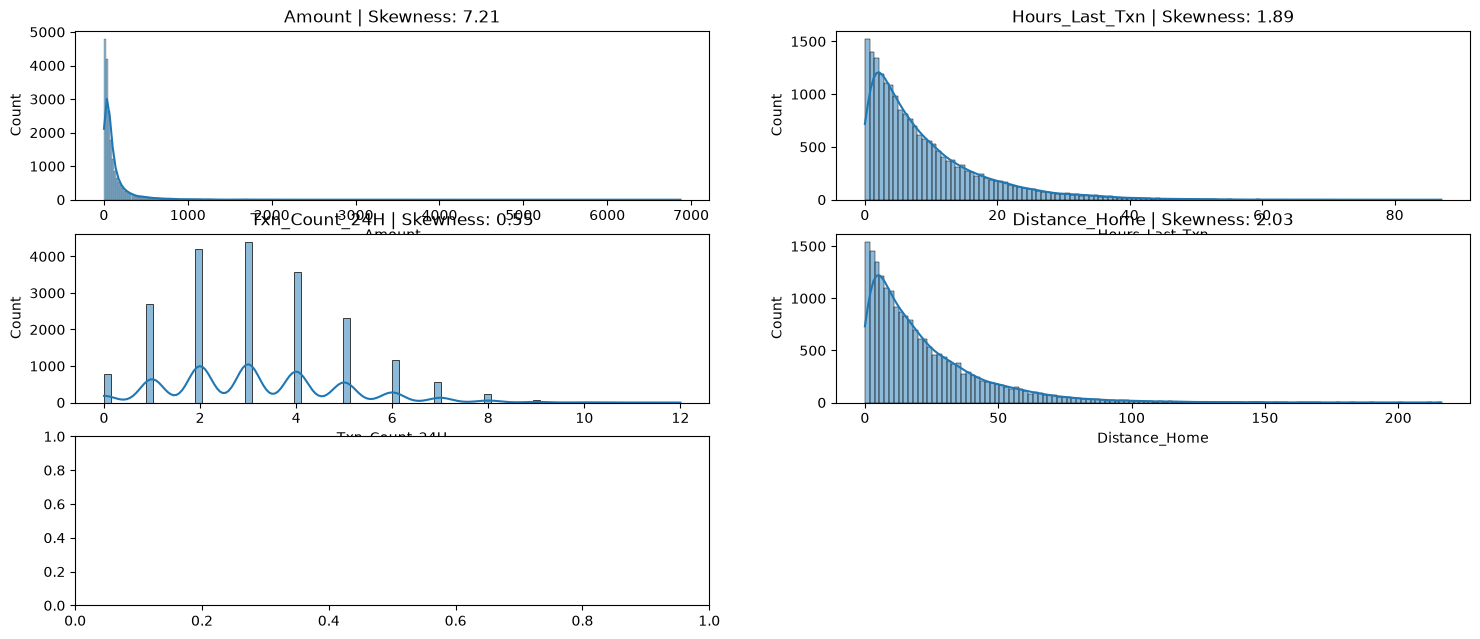

In [58]:
# numeric colum n grapgh represent 
t = 1

plt.figure(figsize=(18, 18))

for i in num_col:
    plt.subplot(7, 2, t)
    
    sns.histplot(df[i], kde=True)
    
    plt.title(f"{i} | Skewness: {round(df[i].skew(), 2)}")
    
    t += 1

plt.tight_layout()
plt.show()

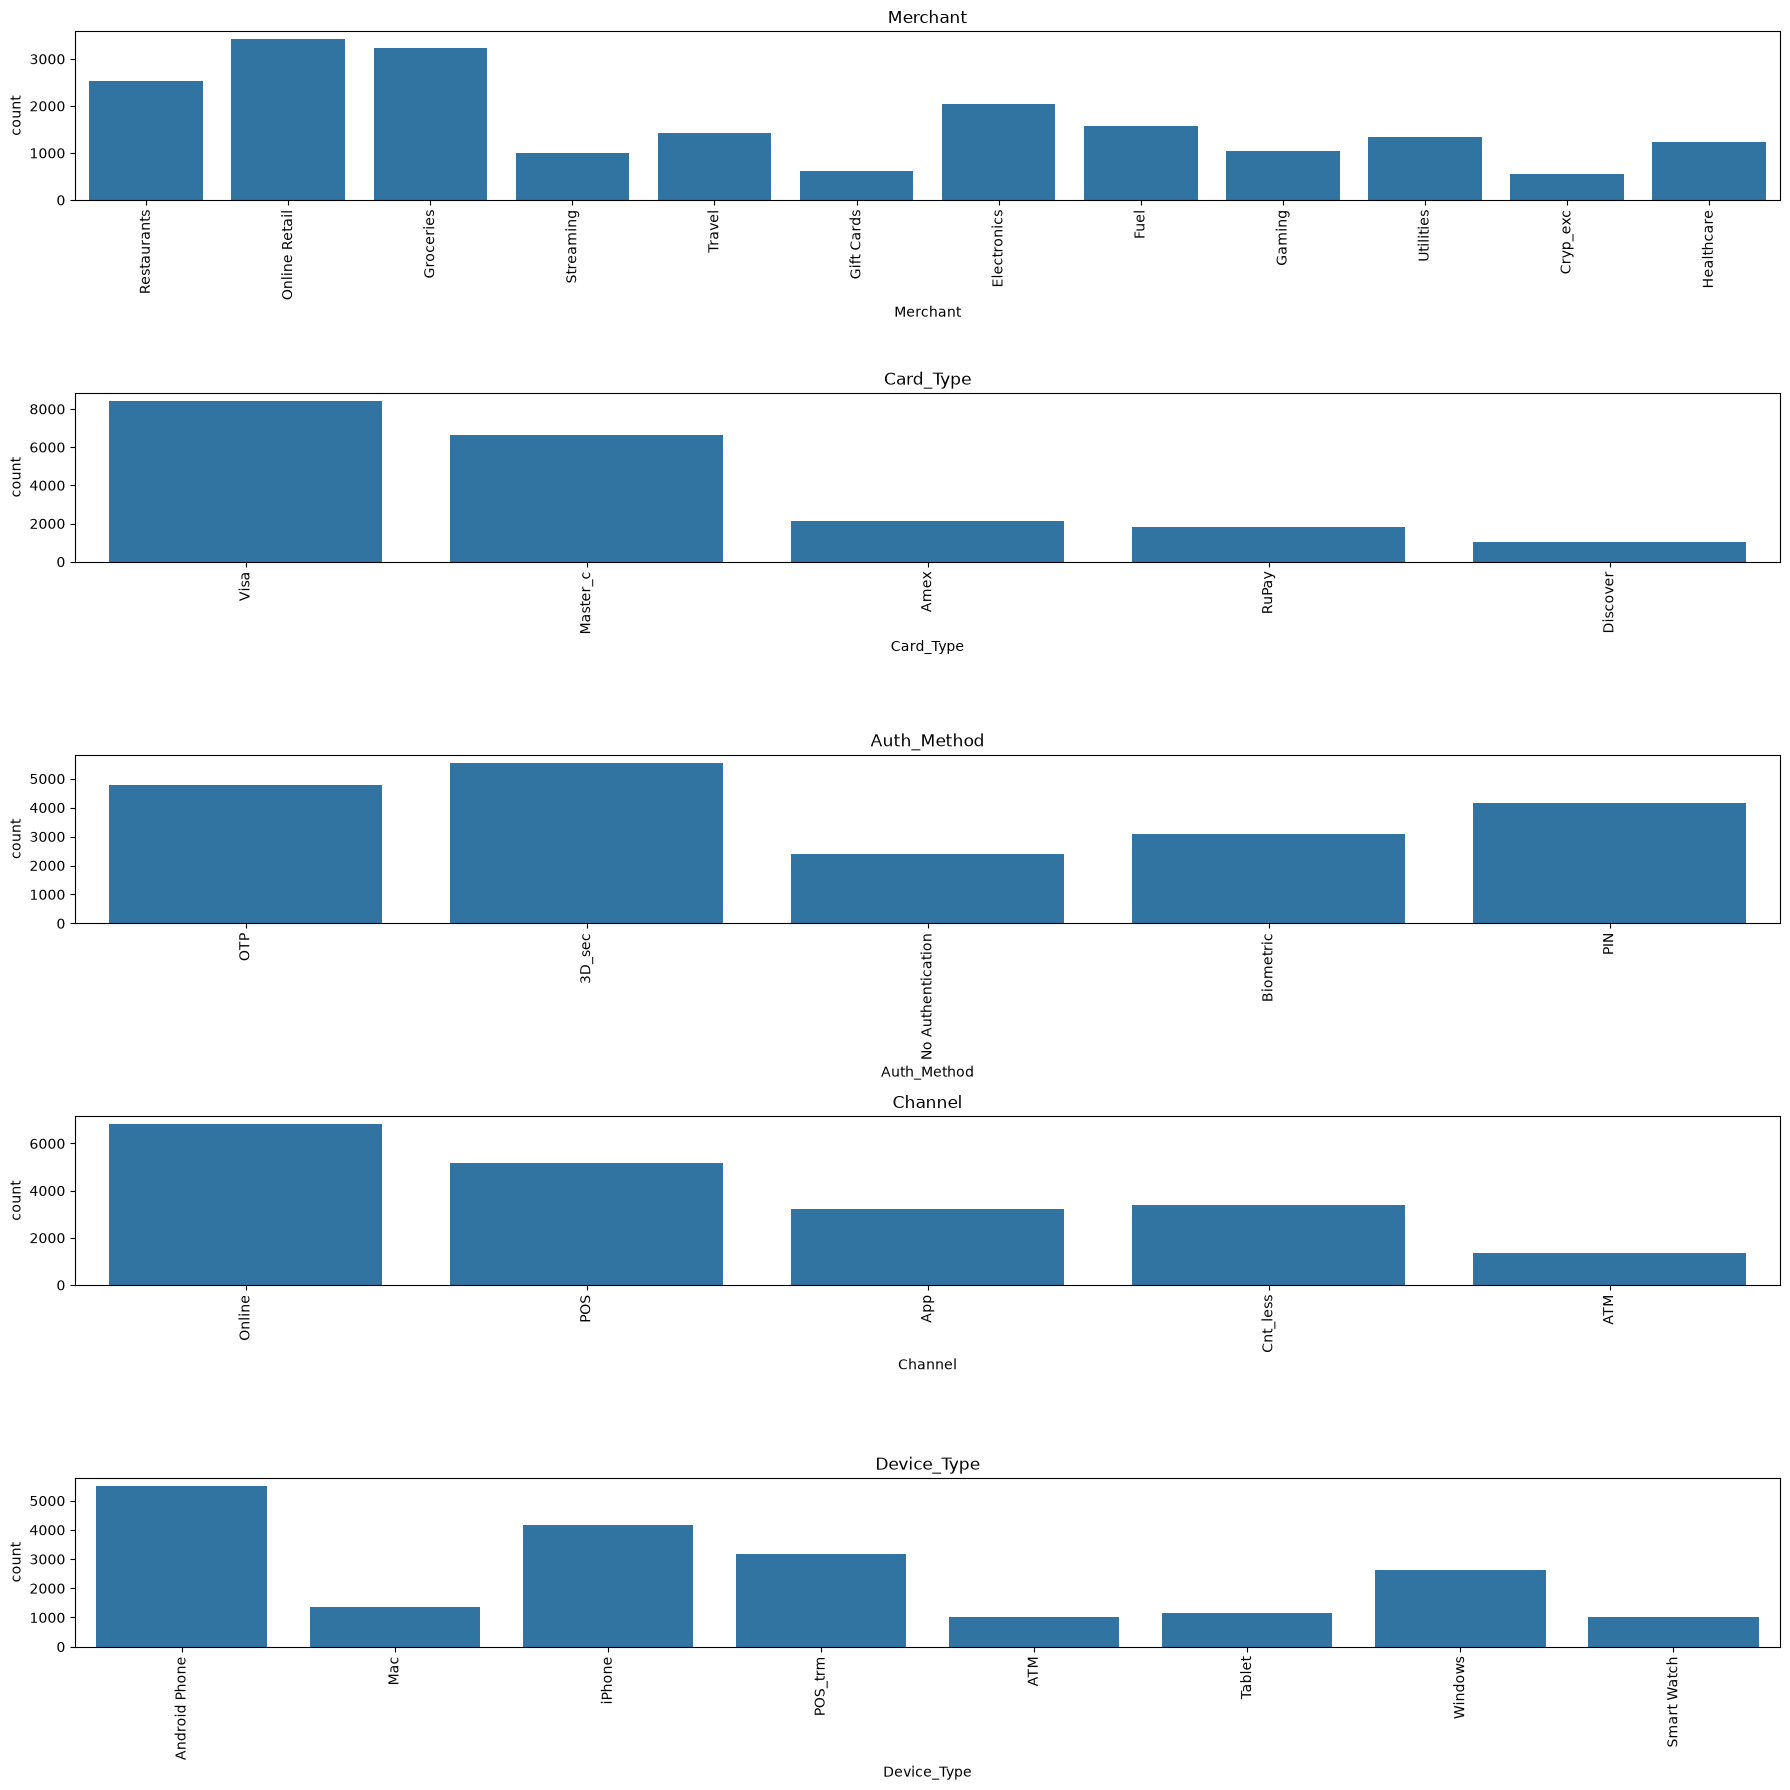

In [57]:
# cat col 
t = 1

plt.figure(figsize=(18, 18))

for i in cat_col:
    plt.subplot(5, 1, t)
    sns.countplot(data=df, x=df[i])
    plt.xticks(rotation=90)
    plt.title(i)
    t += 1

plt.tight_layout()
plt.show()

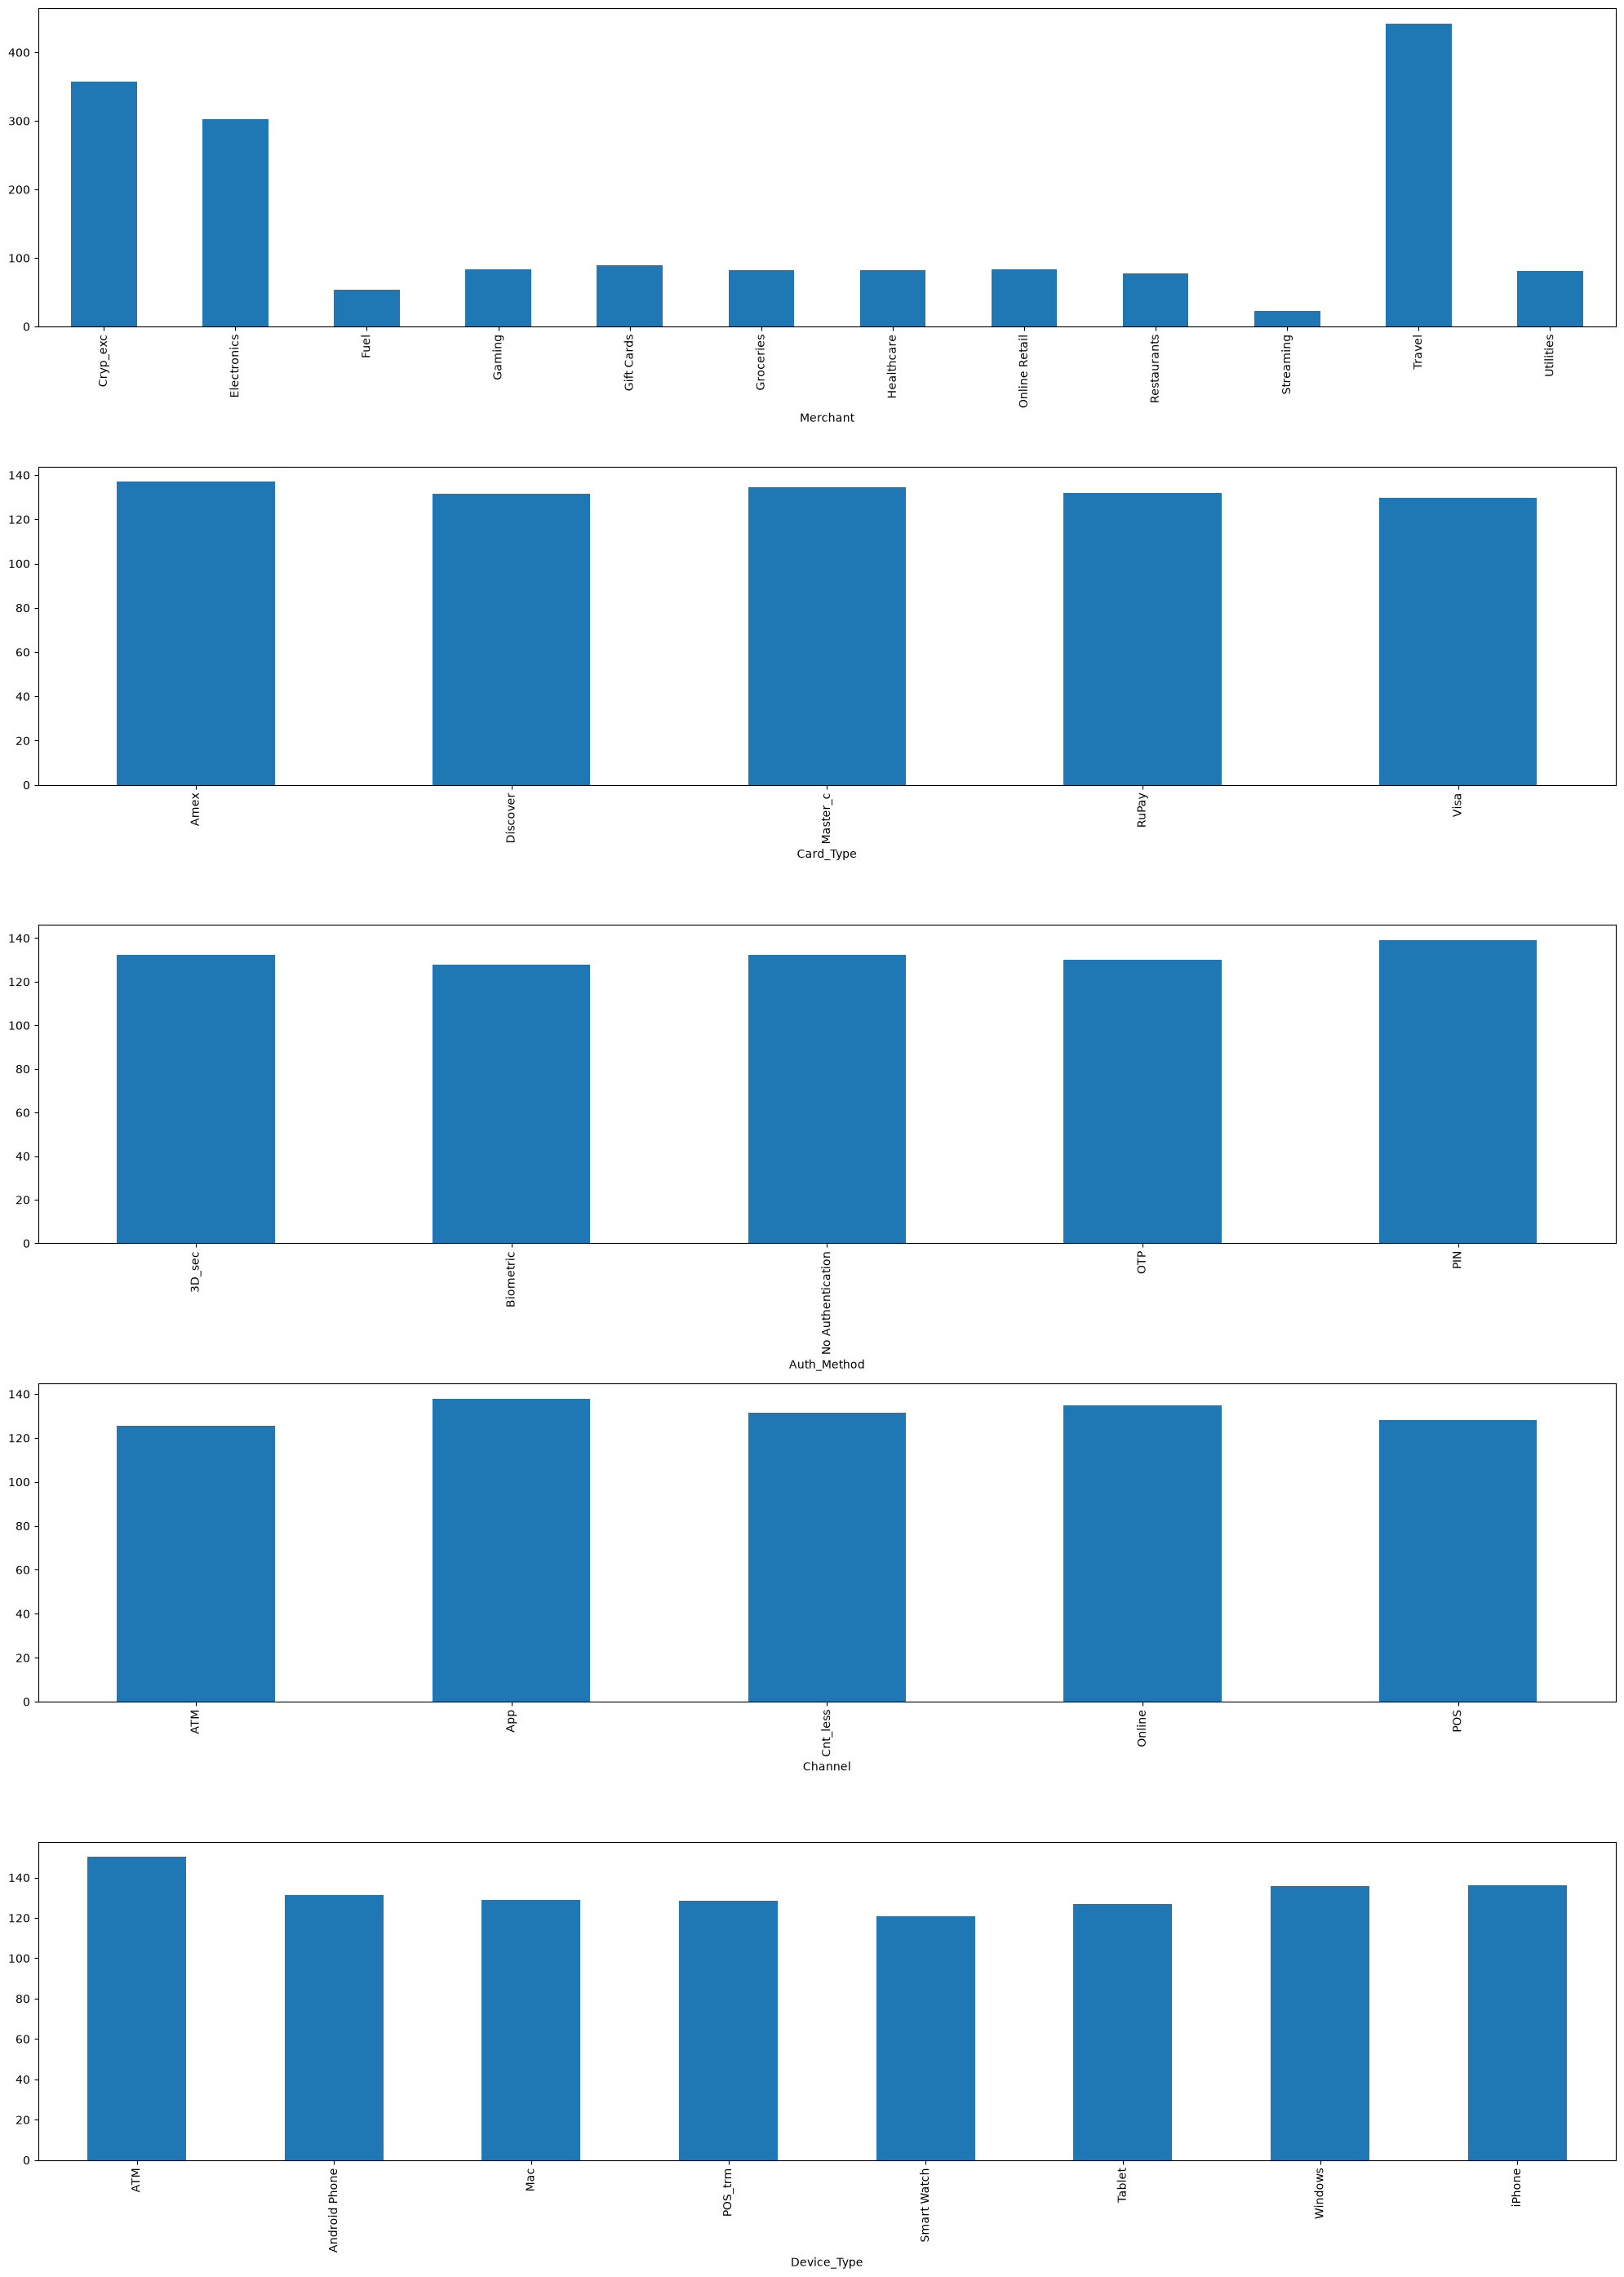

In [62]:
t = 1

plt.figure(figsize=(20, 28))

for i in cat_col:
    plt.subplot(5, 1, t)
    df.groupby(i)['Amount'].mean().plot(kind='bar')
    plt.xticks(rotation=90)
    t += 1

plt.tight_layout()
plt.show()


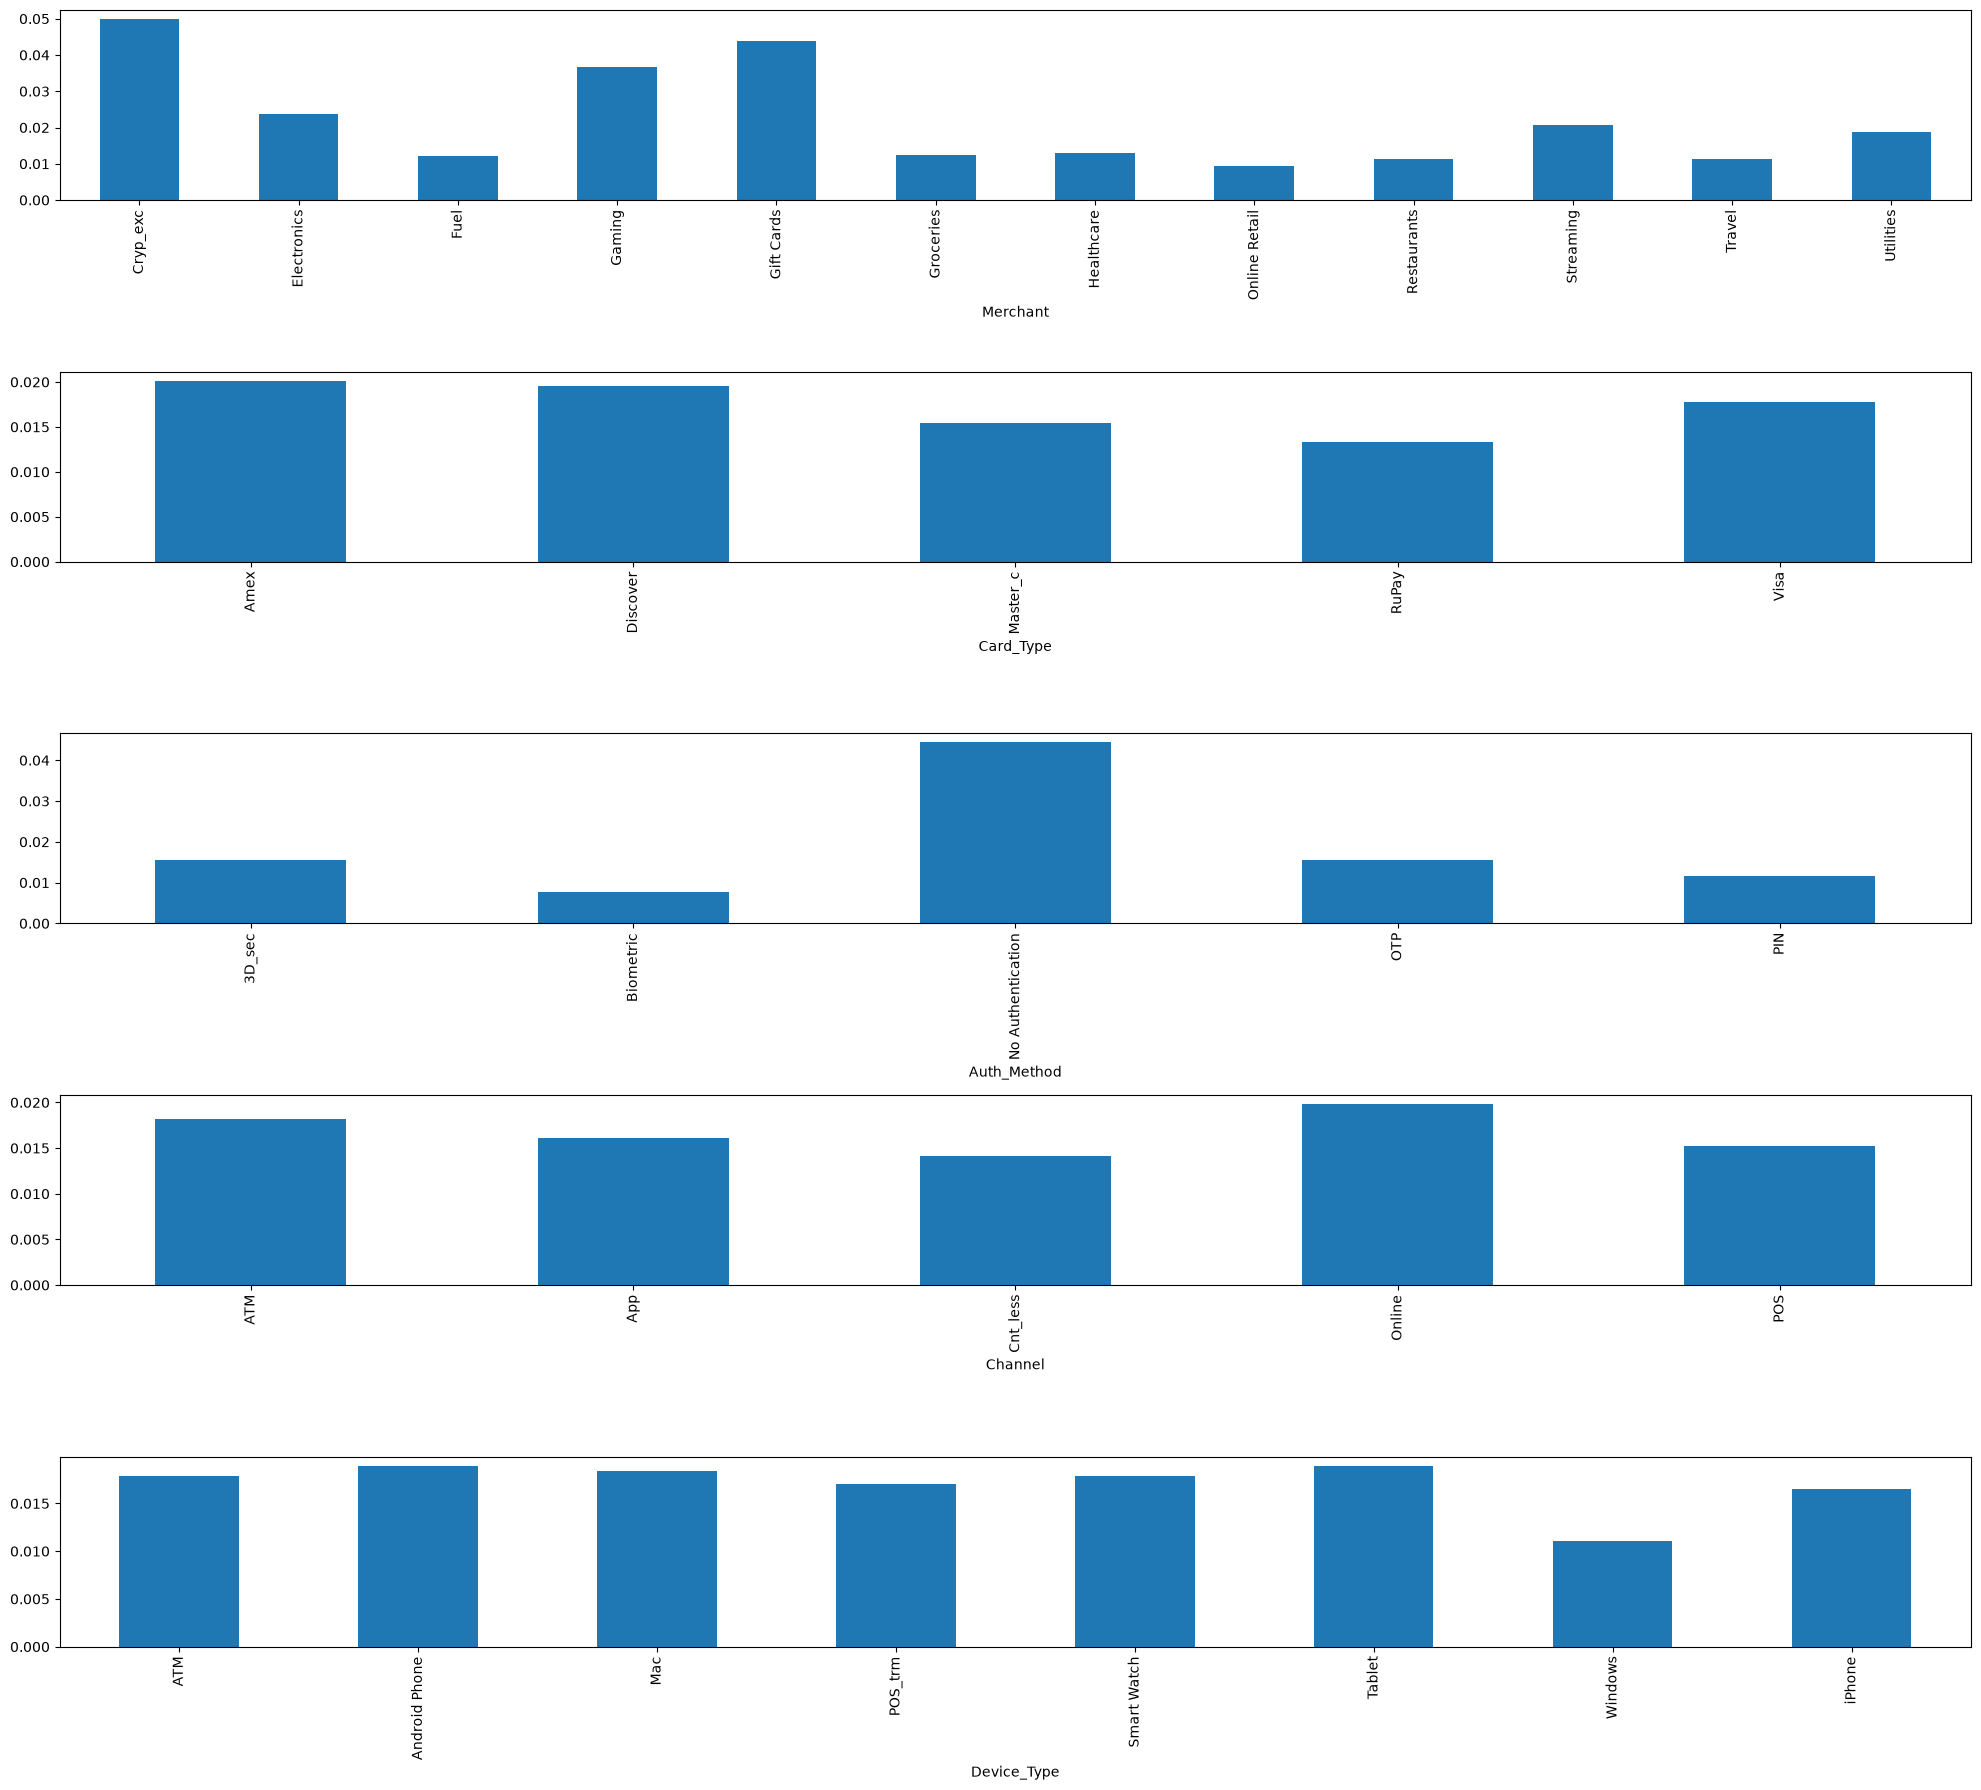

In [65]:
t = 1

plt.figure(figsize=(20, 18))

for i in cat_col:
    plt.subplot(5, 1, t)
    df.groupby(i)['Fraud'].mean().plot(kind='bar')
    plt.xticks(rotation=90)
    t += 1

plt.tight_layout()
plt.show()


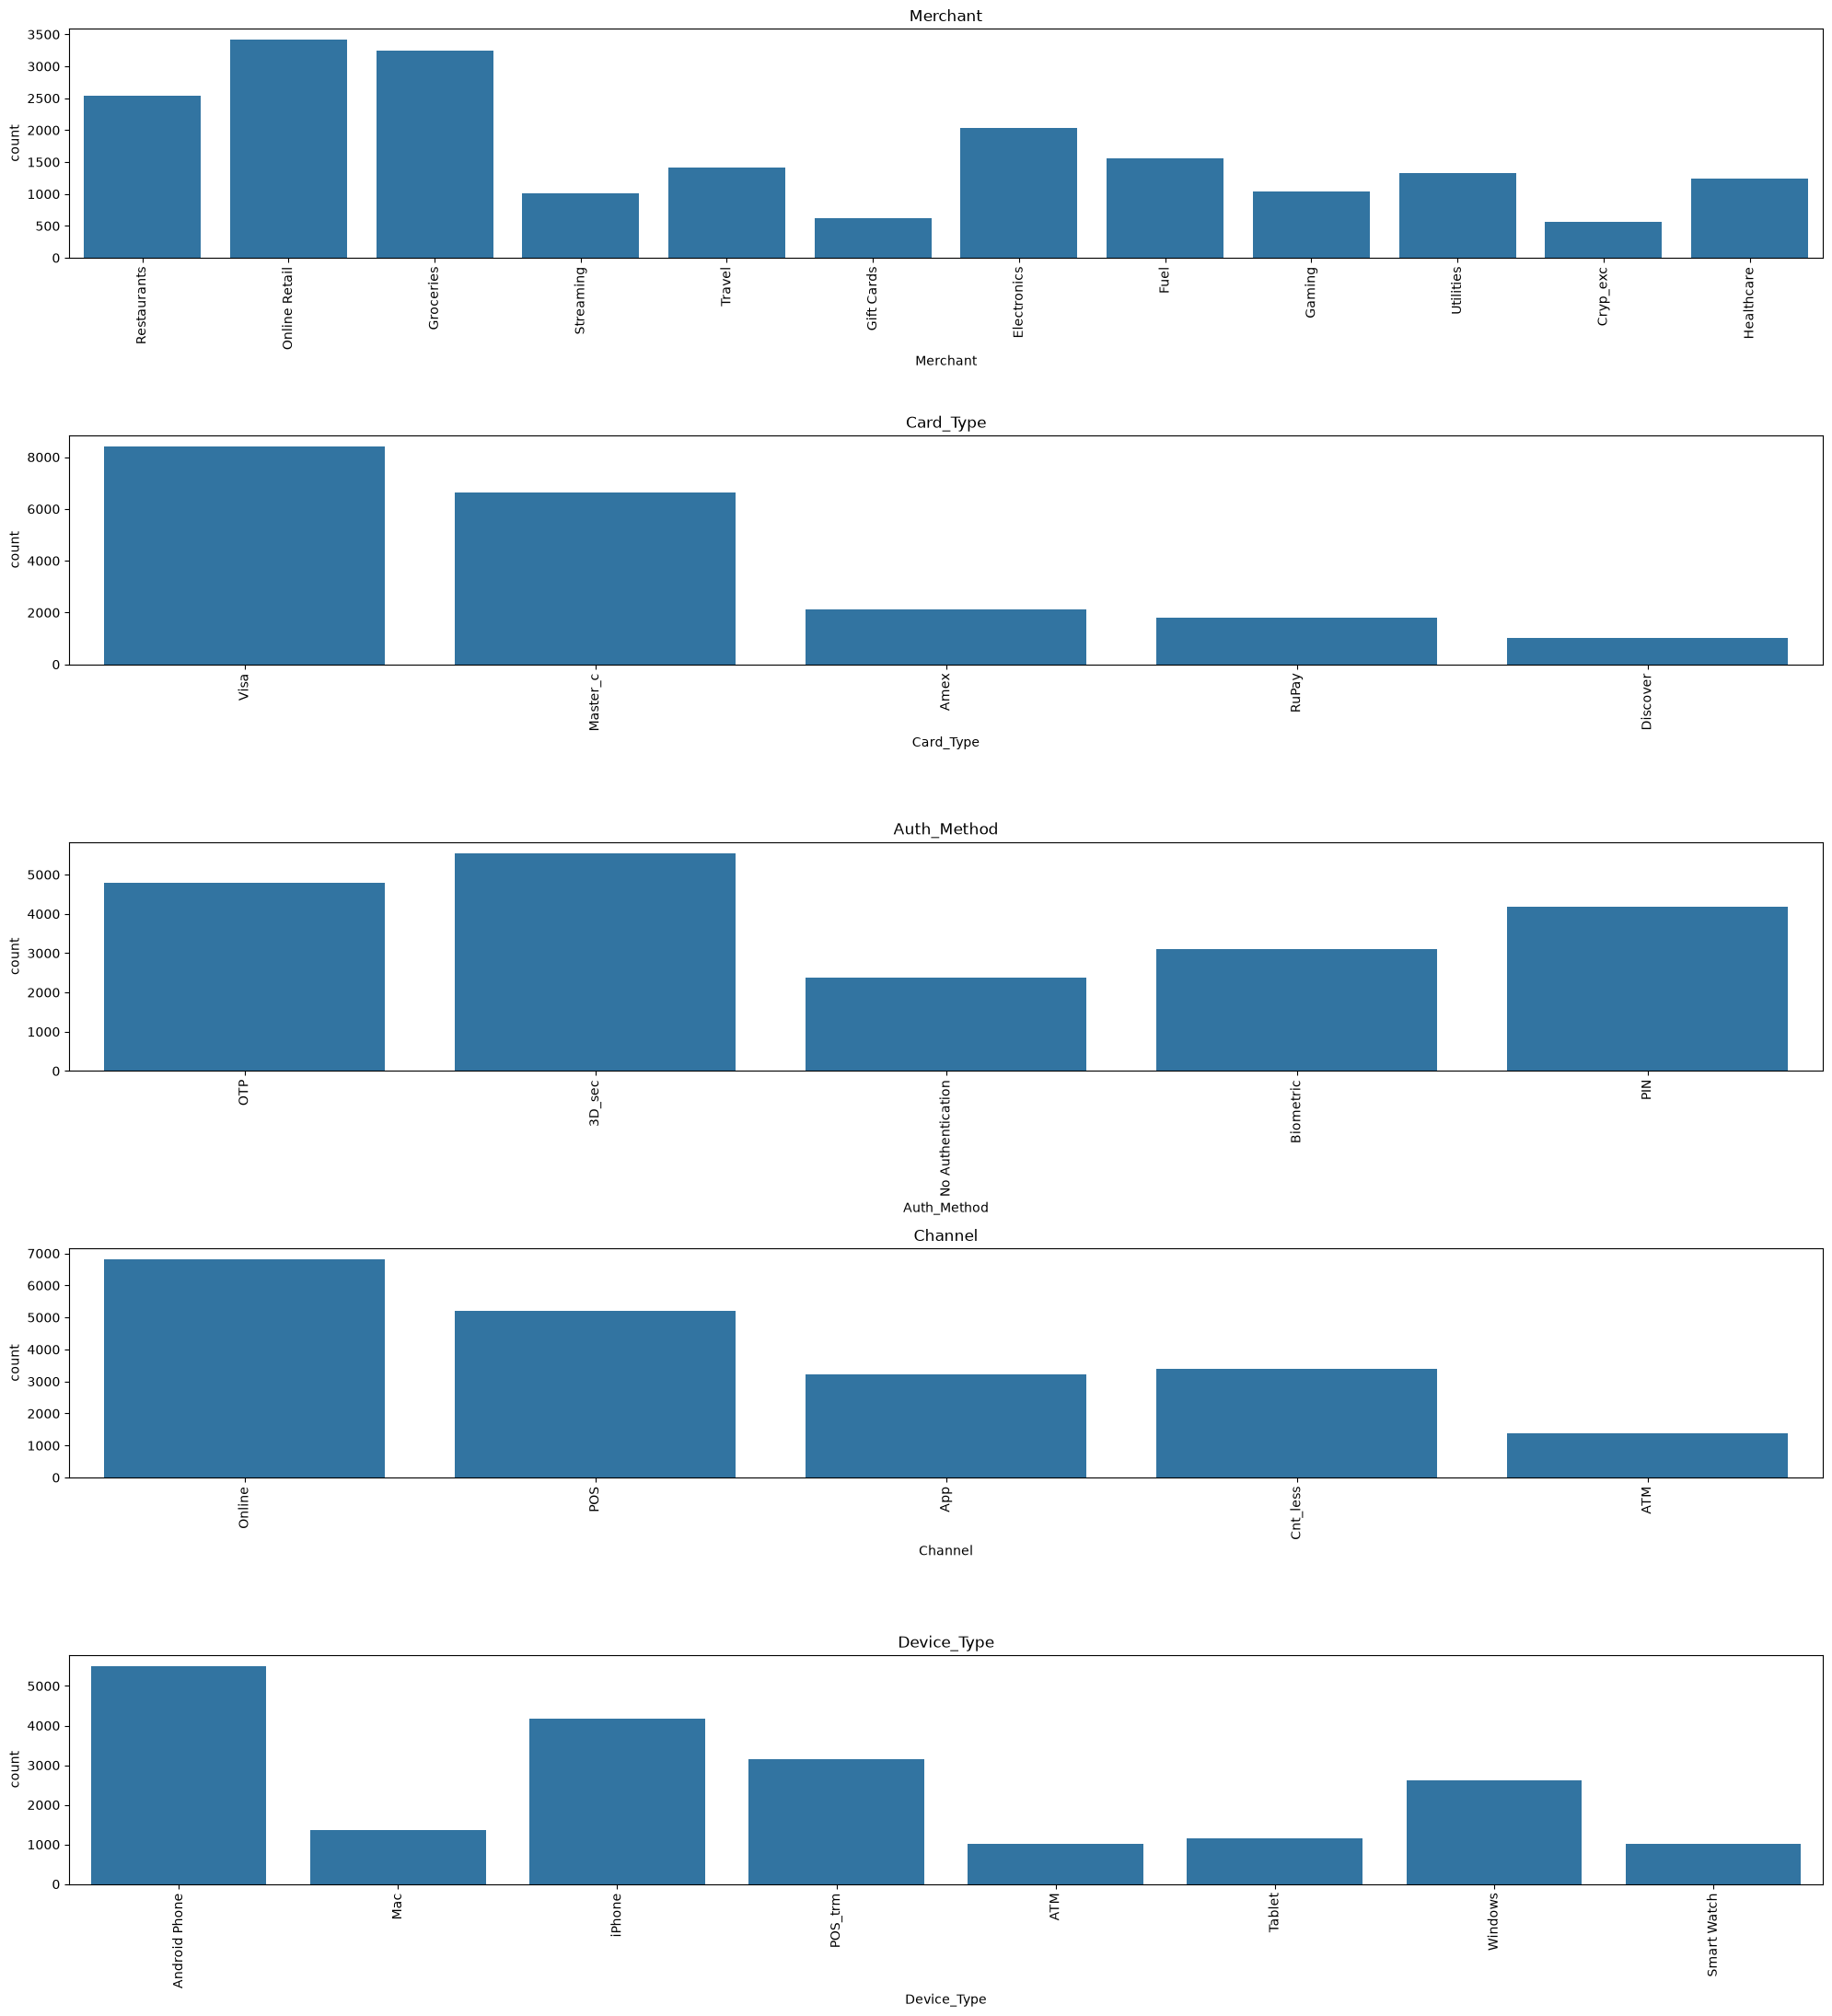

In [67]:
t = 1

plt.figure(figsize=(20, 22))

for i in cat_col:
    plt.subplot(5, 1, t)
    sns.countplot(data=df,x=df[i])
    plt.xticks(rotation=90)
    plt.title(i)
    t += 1

plt.tight_layout()
plt.show()